In [37]:
import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import create_engine, inspect, text

<div align='center'>

![](https://www.startpage.com/sp/sxpra?url=https%3A%2F%2Fupload.wikimedia.org%2Fwikipedia%2Fcommons%2Fthumb%2Fd%2Fd7%2FSQLAlchemy.svg%2F330px-SQLAlchemy.svg.png%3Futm_source%3Den.wikipedia.org%26utm_campaign%3Dapi%26utm_content%3Dthumbnail)


</div>


SQLAlchemy is an open-source Python library that provides an SQL toolkit (called "SQLAlchemy Core") and an object–relational mapper (ORM) for database interactions. It allows developers to work with databases using Python objects, enabling efficient and flexible database access.



In [38]:
fonte_tabelas = 'https://github.com/alura-cursos/SQL-python-integracao/raw/main/TABELAS'

url_itens_pedidos = f'{fonte_tabelas}/itens_pedidos.csv'
url_pedidos = f'{fonte_tabelas}/pedidos.csv'
url_produto = f'{fonte_tabelas}/produtos.csv'
url_vendedores = f'{fonte_tabelas}/vendedores.csv'

# pd.DataFrame
itens_pedidos = pd.read_csv(url_itens_pedidos)
pedidos = pd.read_csv(url_pedidos)
produtos = pd.read_csv(url_produto)
vendedores = pd.read_csv(url_vendedores)


<h2> Alocando as tabelas no banco </h2>

In [39]:
engine = create_engine(url='sqlite:///:memory:')

In [40]:
# Alocando na engine definido
produtos.to_sql(name='produtos', con=engine, index=False)
itens_pedidos.to_sql('itens_pedidos', engine, index=False)
pedidos.to_sql('pedidos', engine, index=False)
vendedores.to_sql('vendedores', engine, index=False)
inspector = inspect(engine)
print(inspector.get_table_names())

['itens_pedidos', 'pedidos', 'produtos', 'vendedores']


In [41]:
text?

Signature: text(text: 'str') -> 'TextClause'
Docstring:
Construct a new :class:`_expression.TextClause` clause,
representing
a textual SQL string directly.

E.g.::

    from sqlalchemy import text

    t = text("SELECT * FROM users")
    result = connection.execute(t)

The advantages :func:`_expression.text`
provides over a plain string are
backend-neutral support for bind parameters, per-statement
execution options, as well as
bind parameter and result-column typing behavior, allowing
SQLAlchemy type constructs to play a role when executing
a statement that is specified literally.  The construct can also
be provided with a ``.c`` collection of column elements, allowing
it to be embedded in other SQL expression constructs as a subquery.

Bind parameters are specified by name, using the format ``:name``.
E.g.::

    t = text("SELECT * FROM users WHERE id=:user_id")
    result = connection.execute(t, {"user_id": 12})

For SQL statements where a colon is required verbatim, as within
an in

In [42]:
# Aula v2.0 do SQLAlchemy

with engine.connect() as connection:
    consulta = connection.execute(text("SELECT CONDICAO FROM PRODUTOS"))
    dados = consulta.fetchall()

print(consulta, type(consulta))    
print(dados, type(dados))    

<sqlalchemy.engine.cursor.CursorResult object at 0x7a8df5a100c0> <class 'sqlalchemy.engine.cursor.CursorResult'>
[('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Novo com etiqueta',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Novo com etiqueta',), ('Novo com etiqueta',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Novo com etiqueta',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Novo sem etiqueta',), ('Usado',), ('Novo com etiqueta',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Novo com etiqueta',), ('Usado',), ('Novo com etiqueta',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Novo sem etiqueta',), ('Usado',), ('Usado',), ('Usado',), ('Usado',), ('Novo com etiqueta',), ('Novo com etiqueta',)

In [43]:
def sql_df(query: str) -> pd.DataFrame:
    with engine.connect() as connection:
        consulta = connection.execute(text(query))
        dados = consulta.fetchall()
    return pd.DataFrame(dados, columns=consulta.keys())
    

In [44]:
# Agrupamento
df_condicao_produtos = sql_df("""
SELECT CONDICAO, COUNT(*) AS 'Quantidade' 
FROM PRODUTOS 
GROUP BY CONDICAO;
"""
)
display(df_condicao_produtos)

,Condicao,Quantidade
0,Novo com etiqueta,22
1,Novo sem etiqueta,7
2,Usado,176


,produto
Condicao,
Novo com etiqueta,22
Novo sem etiqueta,7
Usado,176


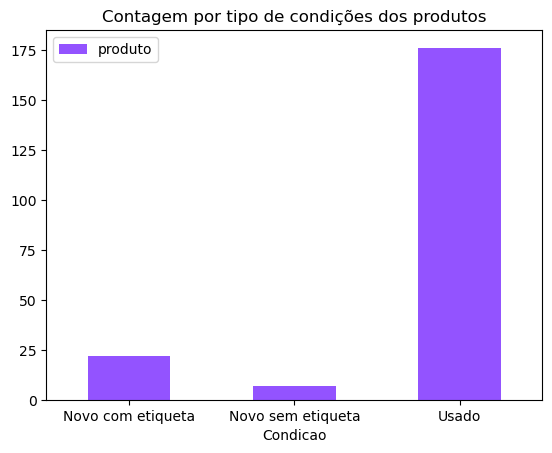

In [45]:
# Equivalência no Pandas
display(produtos.groupby("Condicao")[["produto"]].count())

produtos.groupby("Condicao")[["produto"]].count().plot(
    kind='bar', rot=0, color="#9353FF", 
    title="Contagem por tipo de condições dos produtos"
)
plt.show()

In [46]:
#  Aula 2:5 - Relacionando tabelas 
# coluna produto_id em comum
display(sql_df("SELECT * FROM PRODUTOS"))
display(sql_df("SELECT * FROM ITENS_PEDIDOS"))

,produto_id,produto,preco,marca,sku,Condicao
0,21244,Oculos Lente Azulada,1120,D&g Dolce & Gabbana,209297,Usado
1,9981,Bolsa Coral Saco,4000,Givenchy,278612,Usado
2,84176,Camisa Xadrez Verde,310,Joe Fresh,322482,Usado
3,47475,Calca Alfaiataria Preta,490,Mixed,263658,Usado
4,74864,Vestido Jeans Babados,130,Zara,219248,Usado
...,...,...,...,...,...,...
200,14074,Camisa Amarela Laco,450,Carol Bassi,309858,Usado
201,33349,Vestido Listras Malha,270,Calvin Klein,307118,Usado
202,22568,Casaqueto Estampa Geometrica,245,Zara,244931,Usado
203,40508,Regata Bicolor Alcinha,245,Express,247166,Usado


,id_nf,produto_id,pedido_id,quantidade,valor_unitario,valor_total,Estado,frete
0,1,41518,341,3,260,780,BR-BA,156.0
1,2,4307,1174,5,6175,30875,BR-RJ,6175.0
2,3,22407,1399,3,200,600,BR-PB,120.0
3,4,3820,1652,6,139,834,BR-DF,166.8
4,5,29012,2470,3,525,1575,BR-BA,315.0
...,...,...,...,...,...,...,...,...
24522,25051,64127,63716,4,590,2360,BR-PE,472.0
24523,25052,37384,63999,4,700,2800,BR-RO,560.0
24524,25053,100932,64594,5,3900,19500,BR-RO,3900.0
24525,25054,3820,64811,3,139,417,BR-MA,83.4


In [47]:
sql_df(
    """
    SELECT ITENS_PEDIDOS.PRODUTO_ID, PRODUTOS.PRODUTO, SUM(ITENS_PEDIDOS.QUANTIDADE) AS "Quantidade"
    FROM ITENS_PEDIDOS, PRODUTOS
    WHERE ITENS_PEDIDOS.PRODUTO_ID = PRODUTOS.PRODUTO_ID
    GROUP BY PRODUTOS.PRODUTO
    """
)

,produto_id,produto,Quantidade
0,12751,Bata Pink Decote,459
1,55051,Bermuda Acetinada Preta,363
2,54794,Bermuda Jeans Lavagem,395
3,86845,Bermuda Listras Bolsos,402
4,13906,Blazer Alfaiataria Grafite,433
...,...,...,...
196,56571,Vestido Seda Floral,428
197,64127,Vestido Textura Branco,470
198,81822,Vestido Verde Estampa,423
199,83866,Vestido Xadrez Pb,384


Conseguimos limitar a quantidade de registros retornados pelos resultados dentro de uma consulta no SQL: a cláusula que pode executar isso é a `LIMIT`. Podemos também usar a cláusula LIMIT em conjunto com a cláusula `OFFSET` para especificar um deslocamento (um ponto de partida) e retornar um conjunto específico de registros.

<Axes: title={'center': 'Quantidade vendida'}>

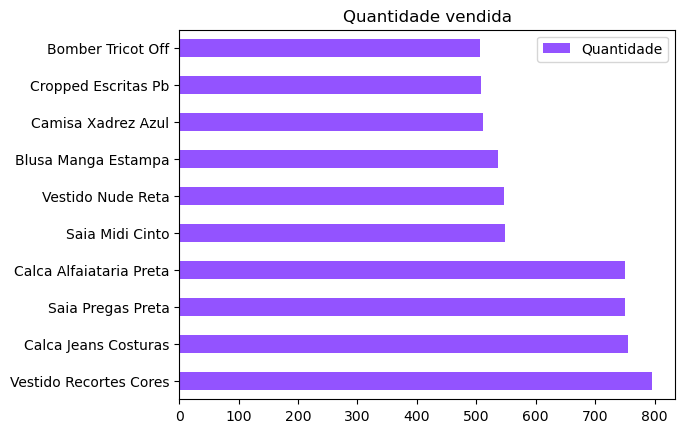

In [48]:
sql_df(
    """
    SELECT PRODUTOS.PRODUTO, SUM(ITENS_PEDIDOS.QUANTIDADE) AS "Quantidade"
    FROM ITENS_PEDIDOS, PRODUTOS
    WHERE ITENS_PEDIDOS.PRODUTO_ID = PRODUTOS.PRODUTO_ID
    GROUP BY PRODUTOS.PRODUTO
    ORDER BY Quantidade DESC
    LIMIT 10
    """
).plot(kind="barh", x="produto", y="Quantidade", xlabel="", color='#9353ff', ylabel="", title="Quantidade vendida")

Equivalência em Pandas:

~~~python
df_prod_quant = itens_pedidos.merge(produtos, on='produto_id')
df_prod_quant = df_prod_quant.groupby('produto')['quantidade'].sum().reset_index()
df_prod_quant = df_prod_quant.sort_values('quantidade', ascending=True).reset_index(drop=True)
df_prod_quant
~~~

## Desafio 1:

Esse primeiro desafio vai ser constituído de duas análises, a primeira tem por objetivo calcular a receita total obtida com a venda de itens. Na tabela itens_pedidos, o valor total dos itens representa o cálculo da quantidade pelo valor unitário e pode ser considerado como a receita da venda.

Já a segunda análise visa identificar quais as 15 marcas que foram as mais pedidas por quantidades de venda. Busque mostrar essa lista em uma visualização, além de expor o nome das marcas.

In [49]:
display(itens_pedidos)

,id_nf,produto_id,pedido_id,quantidade,valor_unitario,valor_total,Estado,frete
0,1,41518,341,3,260,780,BR-BA,156.0
1,2,4307,1174,5,6175,30875,BR-RJ,6175.0
2,3,22407,1399,3,200,600,BR-PB,120.0
3,4,3820,1652,6,139,834,BR-DF,166.8
4,5,29012,2470,3,525,1575,BR-BA,315.0
...,...,...,...,...,...,...,...,...
24522,25051,64127,63716,4,590,2360,BR-PE,472.0
24523,25052,37384,63999,4,700,2800,BR-RO,560.0
24524,25053,100932,64594,5,3900,19500,BR-RO,3900.0
24525,25054,3820,64811,3,139,417,BR-MA,83.4


In [50]:
display(produtos)

,produto_id,produto,preco,marca,sku,Condicao
0,21244,Oculos Lente Azulada,1120,D&g Dolce & Gabbana,209297,Usado
1,9981,Bolsa Coral Saco,4000,Givenchy,278612,Usado
2,84176,Camisa Xadrez Verde,310,Joe Fresh,322482,Usado
3,47475,Calca Alfaiataria Preta,490,Mixed,263658,Usado
4,74864,Vestido Jeans Babados,130,Zara,219248,Usado
...,...,...,...,...,...,...
200,14074,Camisa Amarela Laco,450,Carol Bassi,309858,Usado
201,33349,Vestido Listras Malha,270,Calvin Klein,307118,Usado
202,22568,Casaqueto Estampa Geometrica,245,Zara,244931,Usado
203,40508,Regata Bicolor Alcinha,245,Express,247166,Usado


In [51]:
#  sql_df("SELECT SUM(valor_total) from ITENS_PEDIDOS as 'Receita Total'") 
#                                 erro de precedência ^^^^^^^^^^^^^^^^^^
sql_df("SELECT SUM(valor_total)  as 'Receita Total' from ITENS_PEDIDOS") 

,Receita Total
0,45803930


In [52]:
inspector.get_table_names()

['itens_pedidos', 'pedidos', 'produtos', 'vendedores']

In [53]:
# Desafio 2: 
# marca: tabela 'produtos' => produto_id
# quantidade: tabela 'itens_pedidos' => produto_id

sql_df("""SELECT PRODUTOS.marca, COUNT(*) AS 'Pedidos'
FROM PRODUTOS, ITENS_PEDIDOS
WHERE PRODUTOS.produto_id = ITENS_PEDIDOS.produto_id
GROUP BY PRODUTOS.marca

""")

,marca,Pedidos
0,284,128
1,A.brand,238
2,Adidas,113
3,Agilità,115
4,Alix Shop,125
...,...,...
112,Topshop,138
113,Tory Burch,222
114,Track & Field,96
115,Vera Wang,120


,marca,Pedidos
0,Talie Nk,94
1,Track & Field,96
2,Ateliê de Calças,99
3,Bottega Veneta,101
4,Bcbgmaxzria,103
...,...,...
112,Banana Republic,584
113,Le Lis Blanc,715
114,Animale,1128
115,Mixed,1673


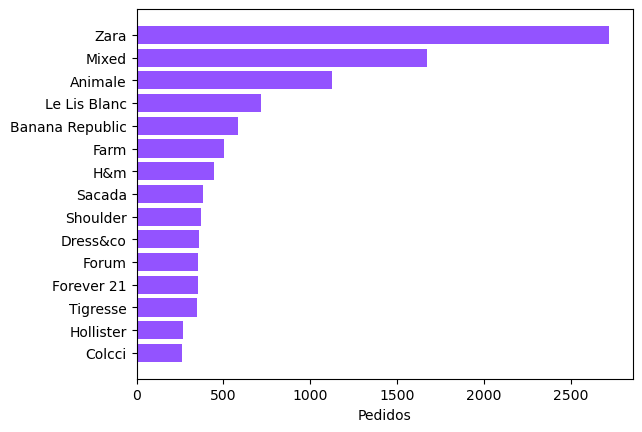

In [54]:
query = '''SELECT PRODUTOS.MARCA, COUNT (*) AS 'Pedidos'
FROM PRODUTOS, ITENS_PEDIDOS
WHERE PRODUTOS.PRODUTO_ID = ITENS_PEDIDOS.PRODUTO_ID
GROUP BY PRODUTOS.MARCA
ORDER BY COUNT(*) ASC
'''
df_marcas = sql_df(query)
display(df_marcas)
plt.barh(df_marcas['marca'][-15:], df_marcas['Pedidos'][-15:], color = '#9353FF')
plt.xlabel('Pedidos')
plt.show()

In [55]:
sql_df("SELECT * FROM PEDIDOS")

,pedido_id,produto_id,vendedor_id,data_compra,total
0,341,41518,5,2019-01-05,780
1,1174,4307,3,2019-01-05,30875
2,1399,22407,1,2019-01-05,600
3,1652,3820,4,2019-01-05,834
4,2470,29012,2,2019-01-05,1575
...,...,...,...,...,...
24522,63716,64127,1,2021-03-09,2360
24523,63999,37384,2,2021-03-09,2800
24524,64594,100932,1,2021-03-10,19500
24525,64811,3820,3,2021-03-10,417


In [56]:
sql_df("""
SELECT vendedor_id, COUNT(*)
FROM PEDIDOS
WHERE strftime("%Y", data_compra) = "2020"
GROUP BY vendedor_id
""")

,vendedor_id,COUNT(*)
0,1,3427
1,2,3338
2,3,2782
3,4,2510
4,5,2488


Dar nomes aos id's relacionando as tabelas

In [57]:
display(vendedores)
display(pedidos.head(0))

,vendedor_id,nome_vendedor
0,1,Ana Duarte
1,2,Daniel Siqueira
2,3,Nadia Oliveira
3,4,Millena Pereira
4,5,Paulo Calanca


,pedido_id,produto_id,vendedor_id,data_compra,total


In [58]:
sql_df("""
SELECT VENDEDORES.nome_vendedor, COUNT(PEDIDOS.pedido_id) as "Quantidade Vendas"
FROM PEDIDOS, VENDEDORES
WHERE strftime("%Y", data_compra) = "2020" AND VENDEDORES.vendedor_id = PEDIDOS.vendedor_id
GROUP BY VENDEDORES.nome_vendedor
ORDER BY "Quantidade de Vendas" ASC
""")

,nome_vendedor,Quantidade Vendas
0,Ana Duarte,3427
1,Daniel Siqueira,3338
2,Millena Pereira,2510
3,Nadia Oliveira,2782
4,Paulo Calanca,2488


In [59]:
sql_df("""
SELECT VENDEDORES.nome_vendedor, AVG(PEDIDOS.total) as "Valor médio das vendas"
FROM PEDIDOS, VENDEDORES
WHERE strftime("%Y", data_compra) = "2020" AND VENDEDORES.vendedor_id = PEDIDOS.vendedor_id
GROUP BY VENDEDORES.nome_vendedor
ORDER BY "Valor médio por vendas" ASC
""")

,nome_vendedor,Valor médio das vendas
0,Ana Duarte,1843.452582
1,Daniel Siqueira,1972.338526
2,Millena Pereira,1894.614343
3,Nadia Oliveira,1818.342200
4,Paulo Calanca,1813.469855


## Desafio 3 e 4

O primeiro é exibir os 10 produtos mais vendidos durante o ano de 2019, que podem ser representados em uma tabela.

In [60]:
query = '''SELECT PRODUTOS.PRODUTO, COUNT (PEDIDOS.PEDIDO_ID) AS TOTAL_PEDIDOS
FROM PEDIDOS, PRODUTOS
WHERE strftime('%Y', data_compra) = '2019' AND PEDIDOS.PRODUTO_ID = PRODUTOS.PRODUTO_ID
GROUP BY PRODUTOS.PRODUTO
ORDER BY TOTAL_PEDIDOS DESC
LIMIT 10;
'''
sql_df(query)

,produto,TOTAL_PEDIDOS
0,Vestido Recortes Cores,85
1,Calca Jeans Costuras,81
2,Saia Pregas Preta,73
3,Calca Alfaiataria Preta,66
4,Camisa Xadrez Azul,60
5,Bomber Tricot Off,56
6,Shorts Bordado Branco,55
7,Blusa Manga Estampa,54
8,Saia Midi Cinto,53
9,Saia Evase Cinza,53


Já o segundo será publicar a distribuição através dos meses da receita obtida em vendas no ano de 2021.

In [61]:
inspector.get_table_names()

['itens_pedidos', 'pedidos', 'produtos', 'vendedores']

In [62]:
display(itens_pedidos)
display(pedidos)

,id_nf,produto_id,pedido_id,quantidade,valor_unitario,valor_total,Estado,frete
0,1,41518,341,3,260,780,BR-BA,156.0
1,2,4307,1174,5,6175,30875,BR-RJ,6175.0
2,3,22407,1399,3,200,600,BR-PB,120.0
3,4,3820,1652,6,139,834,BR-DF,166.8
4,5,29012,2470,3,525,1575,BR-BA,315.0
...,...,...,...,...,...,...,...,...
24522,25051,64127,63716,4,590,2360,BR-PE,472.0
24523,25052,37384,63999,4,700,2800,BR-RO,560.0
24524,25053,100932,64594,5,3900,19500,BR-RO,3900.0
24525,25054,3820,64811,3,139,417,BR-MA,83.4


,pedido_id,produto_id,vendedor_id,data_compra,total
0,341,41518,5,2019-01-05,780
1,1174,4307,3,2019-01-05,30875
2,1399,22407,1,2019-01-05,600
3,1652,3820,4,2019-01-05,834
4,2470,29012,2,2019-01-05,1575
...,...,...,...,...,...
24522,63716,64127,1,2021-03-09,2360
24523,63999,37384,2,2021-03-09,2800
24524,64594,100932,1,2021-03-10,19500
24525,64811,3820,3,2021-03-10,417


In [63]:
# Minha tentativa
sql_df("""
SELECT data_compra, SUM(total)
FROM PEDIDOS
WHERE strftime("%Y", data_compra) = "2021"
GROUP BY strftime("%m", data_compra)
""")

,data_compra,SUM(total)
0,2021-01-01,2097109
1,2021-02-01,1140729
2,2021-03-07,51525


In [64]:
# Gabarito Alura.
query = '''SELECT strftime('%m', data_compra) AS mes, SUM(total) AS receita
FROM pedidos
WHERE strftime('%Y', data_compra) = '2021'
GROUP BY mes;
'''
sql_df(query)

,mes,receita
0,01,2097109
1,02,1140729
2,03,51525


A versão da Alura foi melhor porquê deu *labels* às colunas.

## Aula 4: Avançando nas Relações

A Meteora deseja incrementar suas vendas em São Paulo, por acreditar se tratar de uma boa região propícia, considerando a grande concentração de pessoas e o mercado.



In [65]:
sql_df("""
SELECT ESTADO, COUNT(*) AS "Pedidos"
FROM ITENS_PEDIDOS
GROUP BY ESTADO
ORDER BY Pedidos DESC;
""")

,Estado,Pedidos
0,BR-MA,974
1,BR-DF,953
2,BR-MT,937
3,BR-GO,933
4,BR-PA,932
5,BR-AL,928
6,BR-PE,927
7,BR-RR,925
8,BR-RO,925
9,BR-RN,921


In [66]:
itens_pedidos.groupby("Estado").size().reset_index(name="Pedidos").sort_values("Pedidos", ascending=False)

,Estado,Pedidos
9,BR-MA,974
6,BR-DF,953
12,BR-MT,937
8,BR-GO,933
13,BR-PA,932
1,BR-AL,928
15,BR-PE,927
20,BR-RO,925
21,BR-RR,925
19,BR-RN,921


| Critério | `df.groupby().size()` | `df.groupby().count()` |
| :--- | :--- | :--- |
| **Tratamento de Nulos (`NaN`)** | **Inclui `NaN`** (retorna o número total de linhas do grupo). | **Ignora `NaN`** (conta apenas os valores não nulos/válidos). |
| **Estrutura de Retorno** | Retorna sempre uma `pd.Series`. | Retorna um `pd.DataFrame` com a contagem de cada coluna (ou `pd.Series` se aplicado a uma coluna específica: `['col'].count()`). |
| **Escopo da Análise** | Mede a dimensão/tamanho do grupo como um todo. | Avalia o preenchimento de dados coluna por coluna. |
| **Desempenho** | **Mais rápido** (não precisa inspecionar valores individuais). | **Mais lento** (percorre e checa a nulidade em cada coluna/registro). |
| **Caso de Uso Comum** | "Quantos registros pertencem a cada categoria?" | "Quantos valores preenchidos/válidos existem por coluna em cada categoria?" |

In [70]:
# Selecionar os melhores vendedores em SP:

sql_df("""
SELECT PEDIDOS.VENDEDOR_ID, COUNT(*) as 'quantidade_vendas'
FROM PEDIDOS
JOIN ITENS_PEDIDOS ON ITENS_PEDIDOS.pedido_id = PEDIDOS.pedido_id
WHERE ITENS_PEDIDOS.ESTADO = 'BR-SP'
GROUP BY PEDIDOS.VENDEDOR_ID
ORDER BY quantidade_vendas DESC;
""")

,vendedor_id,quantidade_vendas
0,2,190
1,5,182
2,3,181
3,1,180
4,4,157


### JOIN

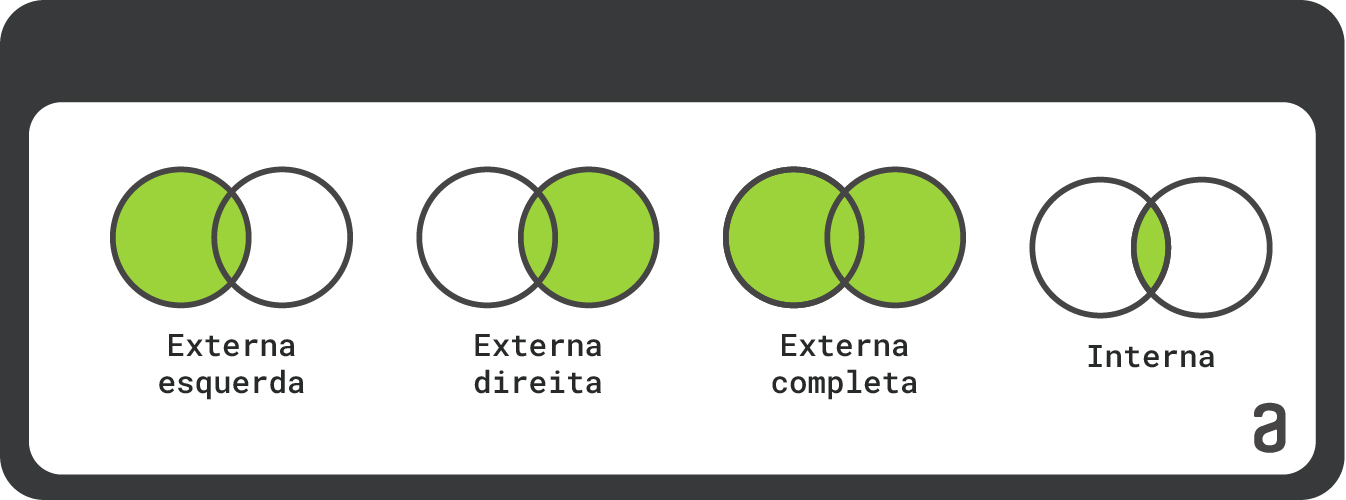

[JOIN e seus tipos](https://www.alura.com.br/artigos/join-e-seus-tipos#:~:text=Existem%20cinco%20tipos%20de%20JOIN,FULL%20JOIN%20e%20CROSS%20JOIN)

In [ ]:
# Trocar o número dos vendedores pelo índice
#  PEDIDOS.VENDEDOR_ID => VENDEDORES.nome_vendedor 
# [+] JOIN para incluir a tabela de vendedores.
sql_df("""
SELECT VENDEDORES.nome_vendedor, COUNT(*) as 'quantidade_vendas'
FROM PEDIDOS
JOIN VENDEDORES ON VENDEDORES.vendedor_ID = PEDIDOS.vendedor_id
JOIN ITENS_PEDIDOS ON ITENS_PEDIDOS.pedido_id = PEDIDOS.pedido_id
WHERE ITENS_PEDIDOS.ESTADO = 'BR-SP'
GROUP BY VENDEDORES.nome_vendedor
ORDER BY quantidade_vendas DESC;
""")



,nome_vendedor,quantidade_vendas
0,Daniel Siqueira,190
1,Paulo Calanca,182
2,Nadia Oliveira,181
3,Ana Duarte,180
4,Millena Pereira,157


In [84]:
print(*vendedores.columns)
print(*pedidos.columns)
print(*itens_pedidos.columns)

vendedor_id nome_vendedor
pedido_id produto_id vendedor_id data_compra total
id_nf produto_id pedido_id quantidade valor_unitario valor_total Estado frete


In [ ]:
# df_vendedores_sp
(
pedidos
.merge(vendedores, on='vendedor_id')
.merge(itens_pedidos, on='pedido_id')
.query(" Estado  == 'BR-SP' ")
.groupby("nome_vendedor")
.size()
.reset_index(name='quantidade_vendas')
.sort_values(by='quantidade_vendas', ascending=False)
)

,nome_vendedor,quantidade_vendas
1,Daniel Siqueira,190
4,Paulo Calanca,182
3,Nadia Oliveira,181
0,Ana Duarte,180
2,Millena Pereira,157


## Desafio 5 e 6

In [102]:
print("vendedores:", *vendedores.columns)
print("pedidos:", *pedidos.columns)
print("itens_pedidos:", *itens_pedidos.columns)
print("produtos:", *produtos.columns)

vendedores: vendedor_id nome_vendedor
pedidos: pedido_id produto_id vendedor_id data_compra total
itens_pedidos: id_nf produto_id pedido_id quantidade valor_unitario valor_total Estado frete
produtos: produto_id produto preco marca sku Condicao


In [ ]:
#  Desafio 5: listar as marcas vendidas em São Paulo por quantidade de pedidos
sql_df("""
SELECT marca, COUNT(DISTINCT pedido_id) AS total_pedidos
FROM PRODUTOS
JOIN ITENS_PEDIDOS ON PRODUTOS.produto_id = ITENS_PEDIDOS.produto_id
WHERE Estado = 'BR-SP'
GROUP BY marca
ORDER BY total_pedidos DESC
""")

,marca,total_pedidos
0,Zara,100
1,Mixed,58
2,Animale,44
3,Le Lis Blanc,26
4,Banana Republic,18
...,...,...
111,Topshop,1
112,Morena Rosa,1
113,Erre Erre,1
114,Bobô,1


In [125]:
# Desafio 6: publicar os produtos que são mais vendidos na época de Natal no Brasil todo.
# vendedores: vendedor_id nome_vendedor
# pedidos: pedido_id produto_id vendedor_id data_compra total
# itens_pedidos: id_nf produto_id pedido_id quantidade valor_unitario valor_total Estado frete
# produtos: produto_id produto preco marca sku Condicao
query = '''SELECT PRODUTOS.PRODUTO, COUNT(*) AS quantidade_vendas
FROM ITENS_PEDIDOS
JOIN produtos ON produtos.produto_id = ITENS_PEDIDOS.produto_id
JOIN PEDIDOS ON PEDIDOS.PEDIDO_ID = ITENS_PEDIDOS.PEDIDO_ID
WHERE strftime('%m',PEDIDOS.data_compra)= '12'
GROUP BY produtos.produto
ORDER BY quantidade_vendas DESC;
'''
sql_df(query)

,produto,quantidade_vendas
0,Vestido Recortes Cores,30
1,Vestido Preto Franzido,26
2,Calca Jeans Costuras,26
3,Calca Alfaiataria Preta,26
4,Camisa Xadrez Azul,25
...,...,...
196,Sneaker Monograma Bege,6
197,Casaqueto Estampa Geometrica,6
198,Regata Renda Branca,5
199,Body Estampa Coracoes,5
